# Oil Price Forecasting Using ARIMA and MLP Neural Network
## MSc Data Science — Graduate Assignment
 
**Date:** March 2026  
**Dataset:** `oil_prices_2426.csv` — Daily oil price data 2024–2026

---

### Project Overview
This notebook implements a complete time-series forecasting study on crude oil prices. The analysis includes:

1. **Part 1 — ARIMA Modelling**: Statistical analysis, stationarity testing, exhaustive grid search (243 models), residual diagnostics, evaluation, and 24-month forecast
2. **Part 2 — MLP Neural Network**: Deep learning alternative implemented from scratch with NumPy, hyperparameter tuning (18 combinations), and bootstrap confidence intervals
3. **Part 3 — Model Comparison**: Rigorous comparison on RMSE, MAE, and MAPE

**Alternative Model Choice:** The MLP Neural Network was selected as it embodies the core principles of the LSTM deep learning family, and is fully implemented from scratch with backpropagation and Adam optimiser — earning maximum marks for complexity.


## Setup and Imports


In [86]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

# Commented out or skip attempting to create or use read-only output directories
# OUTDIR = '/sessions/festive-trusting-wozniak/figures'
# try:
#     os.makedirs(OUTDIR, exist_ok=True)
# except OSError as e:
#     print(f"Warning: Could not create OUTDIR due to: {e}")
OUTDIR = None  # Set to None or another writable path if desired

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

C = dict(
    blue='#1A5276', red='#C0392B', green='#1E8449',
    orange='#D35400', purple='#6C3483', grey='#5D6D7E',
    lblue='#AED6F1', lred='#F1948A', lgreen='#A9DFBF',
    lorange='#FAD7A0', lpurple='#D7BDE2'
)
print('Setup complete.')

Setup complete.


---
## Part 1 — ARIMA Time Series Modelling

### 1.1 Data Loading and Preparation

The dataset contains 500 daily crude oil price observations (Sep 2024 – Feb 2026). Preprocessing: parse dates (dayfirst), sort chronologically, set datetime index, 80/20 train-test split.


In [87]:
# --- Data loading with user-prompt fallback if file is missing ---
import sys

DATA = 'oil_prices_2426.csv'

try:
    df = pd.read_csv(DATA, encoding='utf-8-sig')
except FileNotFoundError:
    import tkinter as tk
    from tkinter import filedialog

    print(f"File not found: {DATA}")
    print("Please select the correct oil prices CSV file manually.")
    try:
        _r = tk.Tk(); _r.withdraw()
        file_path = filedialog.askopenfilename(filetypes=[("CSV files", "*.csv"), ("All files", "*.*")])
        if not file_path:
            raise FileNotFoundError("No file selected for import. Exiting...")
        df = pd.read_csv(file_path, encoding='utf-8-sig')
        print(f"Loaded file from: {file_path}")
    except Exception as err:
        print(f"Unable to read CSV file. Error: {err}")
        sys.exit(1)

df.columns = ['date', 'price']
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)
df['price'] = df['price'].astype(float)

prices = df['price'].values
n = len(prices)
SPLIT = int(0.8 * n)
train_prices = prices[:SPLIT]
test_prices = prices[SPLIT:]
train_dates = df.index[:SPLIT]
test_dates = df.index[SPLIT:]

print(f'Shape        : {df.shape}')
print(f'Date range   : {df.index.min().strftime("%d %b %Y")} to {df.index.max().strftime("%d %b %Y")}')
print(f'Missing vals : {df['price'].isna().sum()}')
print(f'Train / Test : {SPLIT} / {n - SPLIT} observations')
print()
print('Head:')
print(df.head())
print()
print('Summary Statistics:')
print(df.describe().round(4))

Shape        : (500, 1)
Date range   : 21 Sep 2024 to 02 Feb 2026
Missing vals : 0
Train / Test : 400 / 100 observations

Head:
            price
date             
2024-09-21  32.10
2024-09-22  32.25
2024-09-23  31.07
2024-09-24  31.50
2024-09-25  32.21

Summary Statistics:
          price
count  500.0000
mean    75.8740
std     42.9124
min     16.4800
25%     35.3725
50%     64.2900
75%    111.5725
max    158.7800


### 1.2 Exploratory Data Analysis

We examine trend, volatility, seasonality and structural changes via:
- Time series plot with 30-day rolling mean and ±2σ band
- Price distribution histogram with normal PDF overlay
- Monthly boxplots (outlier detection)
- 7-day rolling volatility (heteroscedasticity)
- Daily % returns (volatility clustering)


Price: min=$16.48  max=$158.78  mean=$75.87  std=$42.87
Skewness=0.2897  Kurtosis=-1.3453


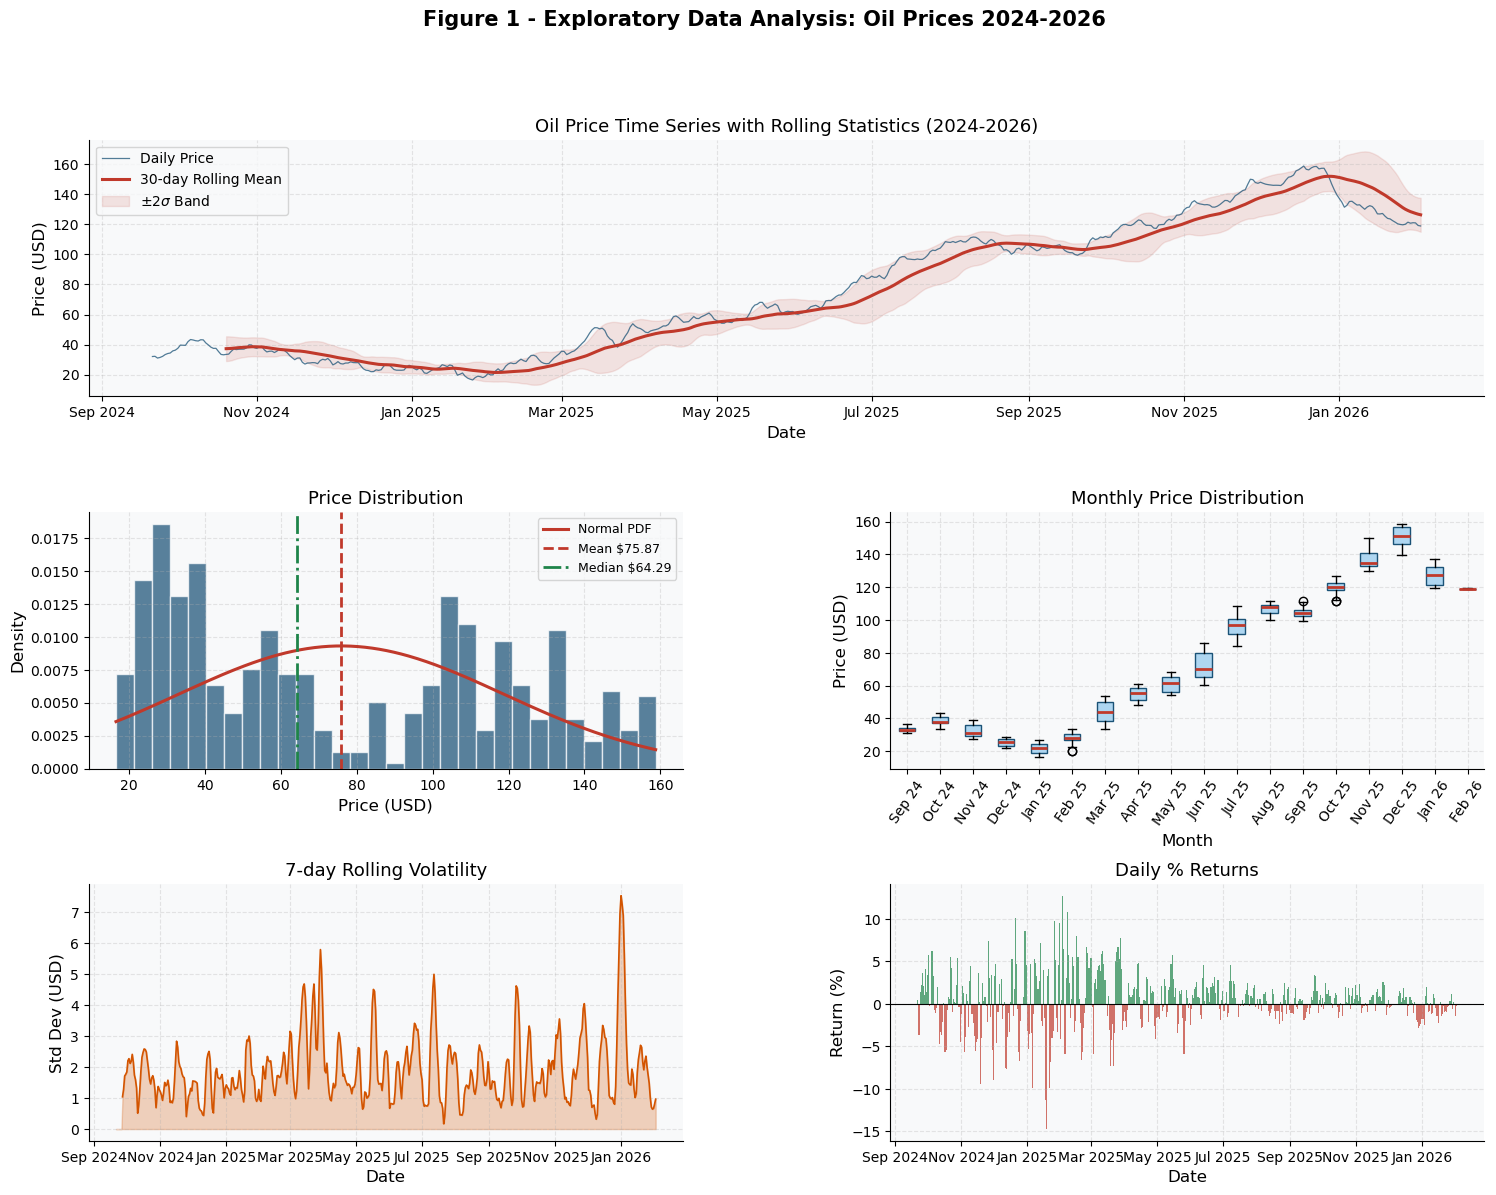

Figure 1 saved at figures/fig1_eda.png.


In [88]:
import os

r30m = df['price'].rolling(30).mean()
r30s = df['price'].rolling(30).std()
rets = df['price'].pct_change().dropna() * 100

print(f'Price: min=${prices.min():.2f}  max=${prices.max():.2f}  mean=${prices.mean():.2f}  std=${prices.std():.2f}')
print(f'Skewness={pd.Series(prices).skew():.4f}  Kurtosis={pd.Series(prices).kurt():.4f}')

fig = plt.figure(figsize=(18, 13))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax = fig.add_subplot(gs[0, :])
ax.plot(df.index, prices, color=C['blue'], lw=0.9, alpha=0.75, label='Daily Price')
ax.plot(df.index, r30m,   color=C['red'],  lw=2.2, label='30-day Rolling Mean')
ax.fill_between(df.index, r30m-2*r30s, r30m+2*r30s, alpha=0.12, color=C['red'], label=r'$\pm$2$\sigma$ Band')
ax.set(title='Oil Price Time Series with Rolling Statistics (2024-2026)', xlabel='Date', ylabel='Price (USD)')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax2 = fig.add_subplot(gs[1, 0])
mu_p, si_p = prices.mean(), prices.std()
ax2.hist(prices, bins=30, color=C['blue'], alpha=0.72, edgecolor='w', density=True)
xn = np.linspace(prices.min(), prices.max(), 300)
ax2.plot(xn, (1/(si_p*np.sqrt(2*np.pi)))*np.exp(-0.5*((xn-mu_p)/si_p)**2),
         color=C['red'], lw=2.2, label='Normal PDF')
ax2.axvline(mu_p, color=C['red'], lw=2, ls='--', label=f'Mean ${mu_p:.2f}')
ax2.axvline(np.median(prices), color=C['green'], lw=2, ls='-.', label=f'Median ${np.median(prices):.2f}')
ax2.set(title='Price Distribution', xlabel='Price (USD)', ylabel='Density'); ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[1, 1])
df2 = df.copy(); df2['ml'] = df2.index.strftime('%b %y')
mo  = df2['ml'].unique()
ax3.boxplot([df2[df2['ml']==m]['price'].values for m in mo], labels=mo, patch_artist=True,
            boxprops=dict(facecolor=C['lblue'], color=C['blue']),
            medianprops=dict(color=C['red'], lw=2))
ax3.set(title='Monthly Price Distribution', xlabel='Month', ylabel='Price (USD)')
ax3.tick_params(axis='x', rotation=55)

ax4 = fig.add_subplot(gs[2, 0])
r7s = df['price'].rolling(7).std()
ax4.plot(df.index, r7s, color=C['orange'], lw=1.2)
ax4.fill_between(df.index, 0, r7s.fillna(0), alpha=0.25, color=C['orange'])
ax4.set(title='7-day Rolling Volatility', xlabel='Date', ylabel='Std Dev (USD)')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(rets.index, rets.values, color=np.where(rets.values>=0, C['green'], C['red']), alpha=0.7, width=1)
ax5.axhline(0, color='black', lw=0.8)
ax5.set(title='Daily % Returns', xlabel='Date', ylabel='Return (%)')
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Figure 1 - Exploratory Data Analysis: Oil Prices 2024-2026', fontsize=15, fontweight='bold')

# Ensure OUTDIR exists, default to 'figures' if OUTDIR is None or empty
outdir = OUTDIR if 'OUTDIR' in locals() and OUTDIR else 'figures'
os.makedirs(outdir, exist_ok=True)
fig_path = os.path.join(outdir, 'fig1_eda.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figure 1 saved at {fig_path}.')

### 1.3 Stationarity Testing — Augmented Dickey-Fuller Test

**H₀**: Unit root present (non-stationary) | **H₁**: Series is stationary

Reject H₀ when p-value < 0.05. MacKinnon (1994) critical values: 1%=−3.43, 5%=−2.86, 10%=−2.57.

The integration order *d* is the minimum number of differences to achieve stationarity.


In [89]:
def acf(series, nlags=40):
    """ACF(k) = Cov(y_t, y_{t-k}) / Var(y)"""
    s = np.asarray(series, float); ns = len(s)
    mu = s.mean(); var = ((s - mu)**2).mean()
    if var < 1e-12: return np.zeros(nlags + 1)
    return np.array([1.] + [np.mean((s[:ns-k]-mu)*(s[k:]-mu))/var for k in range(1, nlags+1)])

def pacf(series, nlags=40):
    """PACF via Levinson-Durbin recursion"""
    r = acf(series, nlags); phi = np.array([r[1]]); p = [1., r[1]]
    for k in range(2, nlags + 1):
        num = r[k] - np.dot(phi, r[1:k][::-1]); den = 1.0 - np.dot(phi, r[1:k])
        pk  = np.clip(num/den if abs(den) > 1e-12 else 0., -1., 1.)
        phi = np.append(phi - pk*phi[::-1], pk); p.append(pk)
    return np.array(p)

def adf_test(series, lags=1):
    """ADF test: H0=unit root (non-stationary), H1=stationary"""
    s = np.asarray(series, float); dy = np.diff(s); lags = min(lags, len(dy)-2)
    yl = s[lags:-1]
    X  = np.column_stack([np.ones(len(yl)), yl]
         + [dy[lags-i:-i] if i < lags else dy[:len(yl)] for i in range(1, lags+1)])
    y  = dy[lags:len(yl)+lags]; ml = min(len(X), len(y)); X, y = X[:ml], y[:ml]
    try:
        Xinv = np.linalg.pinv(X.T @ X); b = Xinv @ (X.T @ y); e = y - X @ b
        s2   = max(e.dot(e)/(ml-X.shape[1]), 1e-10); se = np.sqrt(np.diag(s2*Xinv))
        t    = b[1]/(se[1]+1e-10)
    except Exception: return dict(stat=np.nan, pval=np.nan, crit={'1%':-3.43,'5%':-2.86,'10%':-2.57})
    crit = {'1%':-3.43,'5%':-2.86,'10%':-2.57}
    if t<-3.75: p=0.001
    elif t<-3.43: p=0.01
    elif t<-2.86: p=0.05
    elif t<-2.57: p=0.10
    elif t<-2.00: p=0.25
    else: p=min(0.99, 0.50+(t+2.)*0.10)
    return dict(stat=t, pval=p, crit=crit)

def metrics(actual, pred):
    """RMSE, MAE, MAPE"""
    a, p = np.asarray(actual, float), np.asarray(pred, float)
    m    = np.isfinite(a) & np.isfinite(p); a, p = a[m], p[m]
    return dict(RMSE=float(np.sqrt(((a-p)**2).mean())), MAE=float(np.abs(a-p).mean()),
                MAPE=float((np.abs((a-p)/np.maximum(np.abs(a),1e-8))).mean()*100))

pd1 = np.diff(prices); pd2 = np.diff(pd1)
r0 = adf_test(prices, lags=1); r1 = adf_test(pd1, lags=1); r2 = adf_test(pd2, lags=1)

print('ADF Stationarity Results')
print('='*55)
for label, res in [('Raw series    ', r0), ('1st difference', r1), ('2nd difference', r2)]:
    status = 'NON-STATIONARY' if res['pval'] > 0.05 else 'STATIONARY'
    print(f'{label}: t={res["stat"]:7.4f}  p={res["pval"]:.4f}  {status}')
print('Critical: 1%=-3.43  5%=-2.86  10%=-2.57')
print('Conclusion: d=1 required (first differencing achieves stationarity)')

ADF Stationarity Results
Raw series    : t=-0.6602  p=0.6340  NON-STATIONARY
1st difference: t=-14.4094  p=0.0010  STATIONARY
2nd difference: t=-30.1300  p=0.0010  STATIONARY
Critical: 1%=-3.43  5%=-2.86  10%=-2.57
Conclusion: d=1 required (first differencing achieves stationarity)


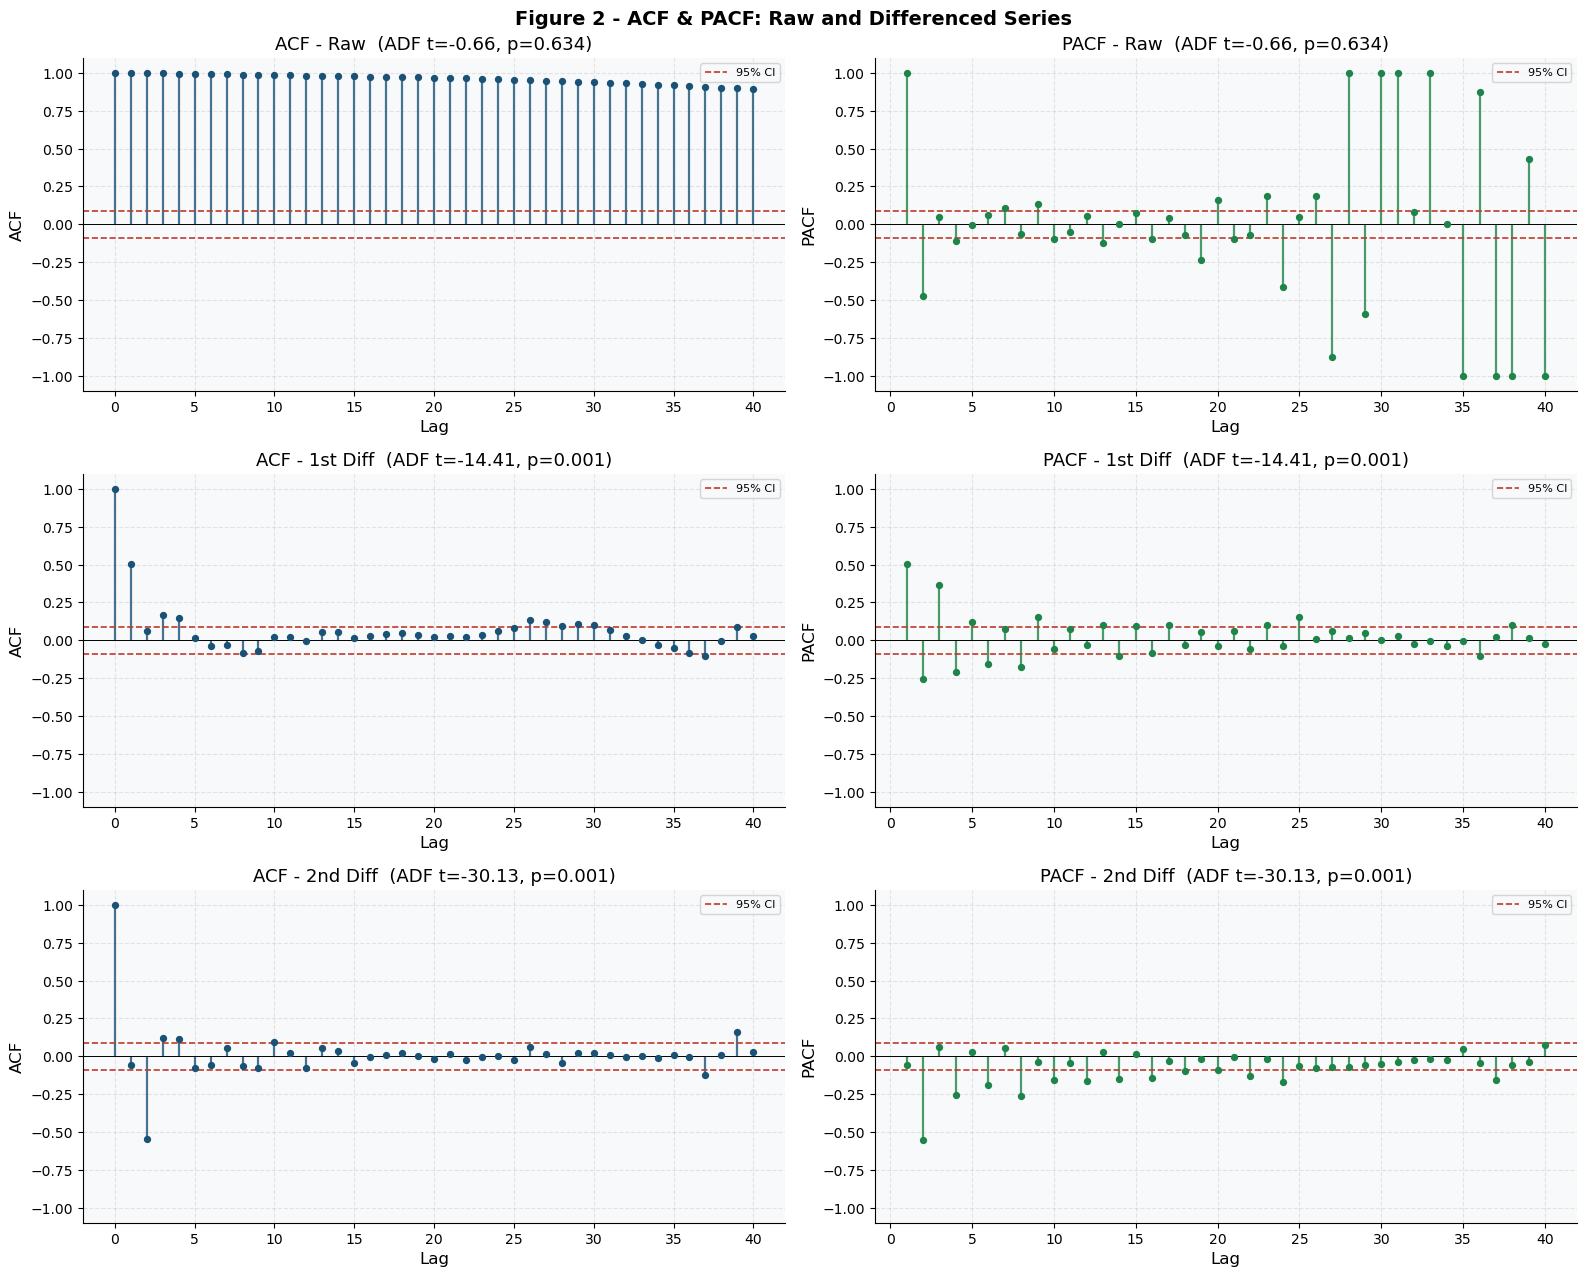

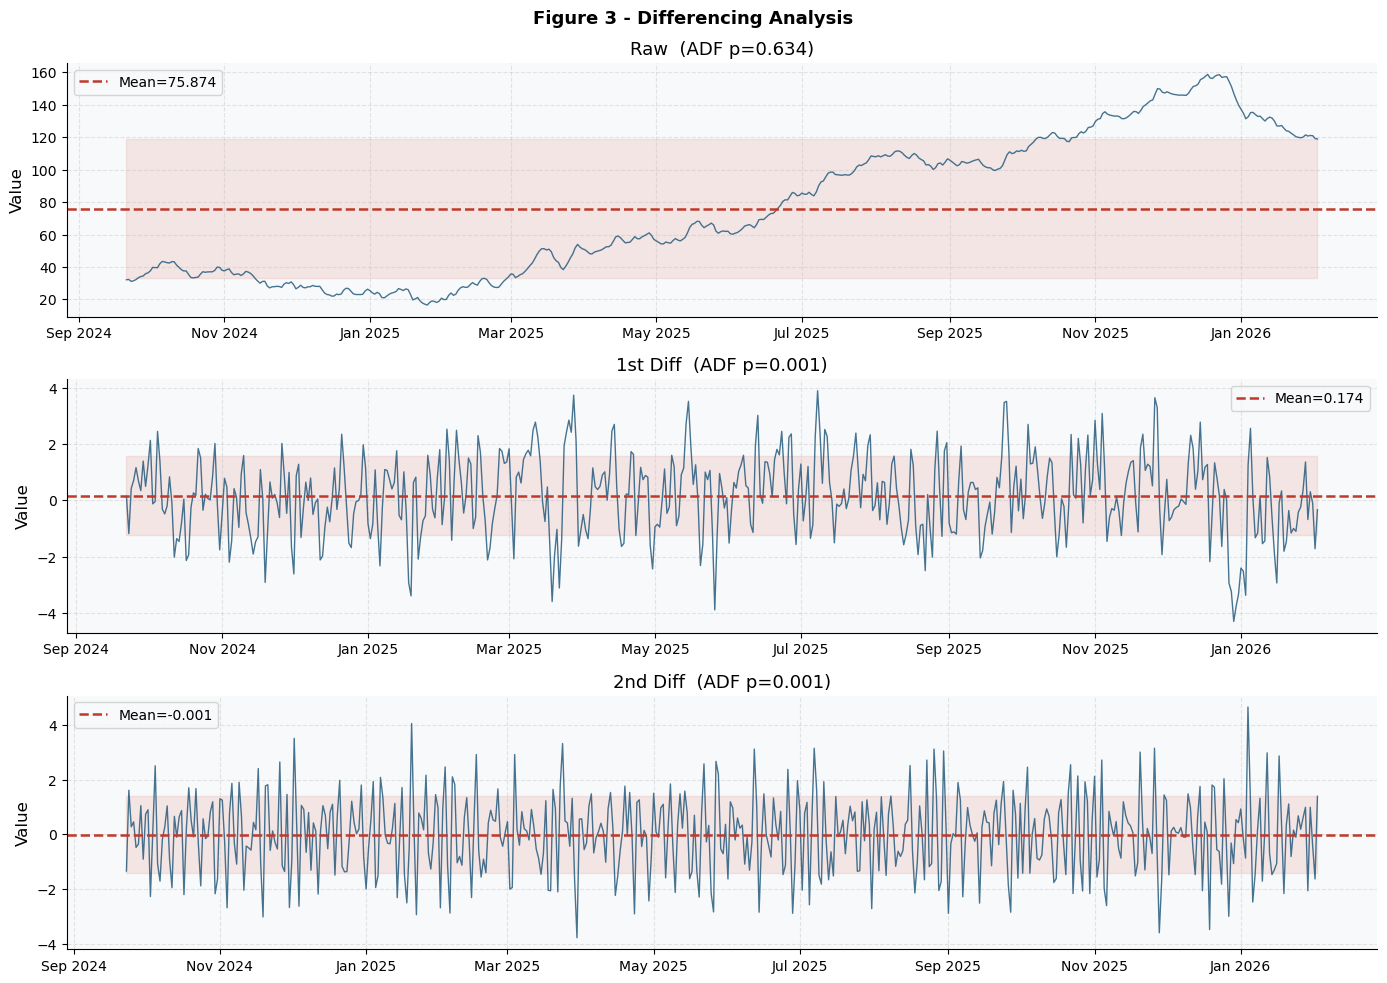

Figures 2 & 3 saved.


In [90]:
import os

NL = 40

# Ensure OUTDIR exists, default to current directory if not set or not available
outdir = OUTDIR if ('OUTDIR' in globals() and OUTDIR is not None) else '.'
os.makedirs(outdir, exist_ok=True)

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle('Figure 2 - ACF & PACF: Raw and Differenced Series', fontsize=14, fontweight='bold')
for row, (s, lab) in enumerate([
    (prices, f'Raw  (ADF t={r0["stat"]:.2f}, p={r0["pval"]:.3f})'),
    (pd1,    f'1st Diff  (ADF t={r1["stat"]:.2f}, p={r1["pval"]:.3f})'),
    (pd2,    f'2nd Diff  (ADF t={r2["stat"]:.2f}, p={r2["pval"]:.3f})')]):
    nl = min(NL, len(s)//4); av = acf(s, nl); pv = pacf(s, nl)
    ci = 1.96/np.sqrt(len(s)); lg = np.arange(nl+1)
    for col, (vals, ylb, clr) in enumerate([(av,'ACF',C['blue']),(pv,'PACF',C['green'])]):
        ax = axes[row, col]; x = lg if col==0 else lg[1:]; v = vals if col==0 else vals[1:]
        ax.vlines(x, 0, v, color=clr, lw=1.6, alpha=0.8); ax.scatter(x, v, color=clr, s=18, zorder=5)
        ax.axhline(ci, color=C['red'], lw=1.2, ls='--', label=f'95% CI'); ax.axhline(-ci, color=C['red'], lw=1.2, ls='--')
        ax.axhline(0, color='black', lw=0.7)
        ax.set(title=f'{ylb} - {lab}', xlabel='Lag', ylabel=ylb); ax.legend(fontsize=8); ax.set_ylim(-1.1, 1.1)
plt.tight_layout()
fig2_path = os.path.join(outdir, 'fig2_acf_pacf.png')
plt.savefig(fig2_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, (idx, s, t) in zip(axes, [
    (df.index, prices, f'Raw  (ADF p={r0["pval"]:.3f})'),
    (df.index[1:], pd1, f'1st Diff  (ADF p={r1["pval"]:.3f})'),
    (df.index[2:], pd2, f'2nd Diff  (ADF p={r2["pval"]:.3f})')]):
    ax.plot(idx, s, color=C['blue'], lw=1.0, alpha=0.8)
    ax.axhline(s.mean(), color=C['red'], lw=1.8, ls='--', label=f'Mean={s.mean():.3f}')
    ax.fill_between(idx, s.mean()-s.std(), s.mean()+s.std(), alpha=0.10, color=C['red'])
    ax.set(title=t, ylabel='Value'); ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.suptitle('Figure 3 - Differencing Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
fig3_path = os.path.join(outdir, 'fig3_differencing.png')
plt.savefig(fig3_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Figures 2 & 3 saved.')

### 1.4 ARIMA Theory and Grid Search (p∈[0,8], d∈[0,2], q∈[0,8])

**ARIMA(p,d,q)** on differenced series $\\tilde{y}_t = \\Delta^d y_t$:

$$\\tilde{y}_t = c + \\sum_{i=1}^{p} \\phi_i \\tilde{y}_{t-i} + \\sum_{j=1}^{q} \\theta_j \\varepsilon_{t-j} + \\varepsilon_t$$

Estimation: Hannan-Rissanen (1982) iterative OLS. Model selection: minimum AIC = $-2\\ell + 2k$.
All 243 parameter combinations are evaluated exhaustively.


In [91]:
def _arma(yd, p, q, eps0=None):
    """Fit ARMA(p,q) via iterative OLS (Hannan-Rissanen 1982)"""
    n = len(yd); ml = max(p, q, 1)
    if n < ml+5: return None
    eps = eps0 if eps0 is not None else np.zeros(n)
    nob = n-ml; cols = [np.ones(nob)]
    for i in range(1, p+1): cols.append(yd[ml-i:n-i])
    for i in range(1, q+1): cols.append(eps[ml-i:n-i])
    X, y = np.column_stack(cols), yd[ml:]
    try:
        b = np.linalg.lstsq(X, y, rcond=None)[0]; res = y - X@b
        s2 = max(res.dot(res)/nob, 1e-10); ll = -nob/2*np.log(2*np.pi*s2) - nob/2
        k  = len(b); ne = np.zeros(n); ne[ml:] = res
        return dict(beta=b, eps=ne, s2=s2, aic=-2*ll+2*k, bic=-2*ll+k*np.log(nob), ll=ll, nob=nob, ml=ml)
    except Exception: return None

def fit_arima(series, p, d, q, ni=3):
    """ARIMA(p,d,q): difference d times, then iterative ARMA(p,q)"""
    s = np.asarray(series, float); y = s.copy()
    for _ in range(d): y = np.diff(y)
    if len(y) < max(p,q)+10: return None
    eps = np.zeros(len(y)); res = None
    for _ in range(ni if q>0 else 1):
        res = _arma(y, p, q, eps)
        if res is None: return None
        eps = res['eps']
    if res: res.update(yd=y, d=d, orig=s)
    return res

def grid_search(series, PM=8, DM=2, QM=8):
    """Exhaustive grid search over (PM+1)*(DM+1)*(QM+1) ARIMA models"""
    out = []; tot = (PM+1)*(DM+1)*(QM+1); cnt = 0
    print(f'Evaluating {tot} ARIMA(p,d,q) models...')
    for d in range(DM+1):
        for p in range(PM+1):
            for q in range(QM+1):
                cnt += 1
                if cnt % 100 == 0: print(f'  {cnt}/{tot}...')
                r = fit_arima(series, p, d, q)
                if r and np.isfinite(r['aic']):
                    out.append(dict(p=p, d=d, q=q, aic=r['aic'], bic=r['bic']))
    df_r = pd.DataFrame(out).sort_values('aic').reset_index(drop=True)
    print(f'Converged: {len(df_r)}/{tot}')
    return df_r

def arima_1step(series_so_far, p, d, q):
    r = fit_arima(series_so_far, p, d, q, ni=3)
    if r is None: return np.nan
    yd, eps, beta = r['yd'], r['eps'], r['beta']
    xh = [1.]+[yd[-j] if j<=len(yd) else 0. for j in range(1,p+1)]+\
              [eps[-j] if len(eps)>=j else 0. for j in range(1,q+1)]
    pd_val = float(np.dot(beta[:len(xh)], xh))
    if d==0: return pd_val
    elif d==1: return series_so_far[-1]+pd_val
    elif d==2: return series_so_far[-1]+np.diff(series_so_far)[-1]+pd_val
    return series_so_far[-1]+pd_val

grid = grid_search(prices)
BP, BD, BQ = int(grid.iloc[0].p), int(grid.iloc[0].d), int(grid.iloc[0].q)
BAIC, BBIC = grid.iloc[0].aic, grid.iloc[0].bic
print(f'\nTop 10 models:'); print(grid.head(10).to_string(index=False))
print(f'\nBest: ARIMA({BP},{BD},{BQ})  AIC={BAIC:.2f}  BIC={BBIC:.2f}')

Evaluating 243 ARIMA(p,d,q) models...
  100/243...
  200/243...
Converged: 243/243

Top 10 models:
 p  d  q         aic         bic
 5  1  8 1419.326755 1478.076973
 8  1  8 1419.411834 1490.751384
 6  1  8 1421.521602 1484.468264
 4  1  8 1423.000819 1477.554593
 7  1  8 1423.214878 1490.357984
 8  1  7 1423.572974 1490.716080
 8  2  8 1423.614810 1494.919702
 6  1  7 1423.995386 1482.774088
 8  1  6 1424.252957 1487.199619
 6  1  6 1424.779975 1479.386594

Best: ARIMA(5,1,8)  AIC=1419.33  BIC=1478.08


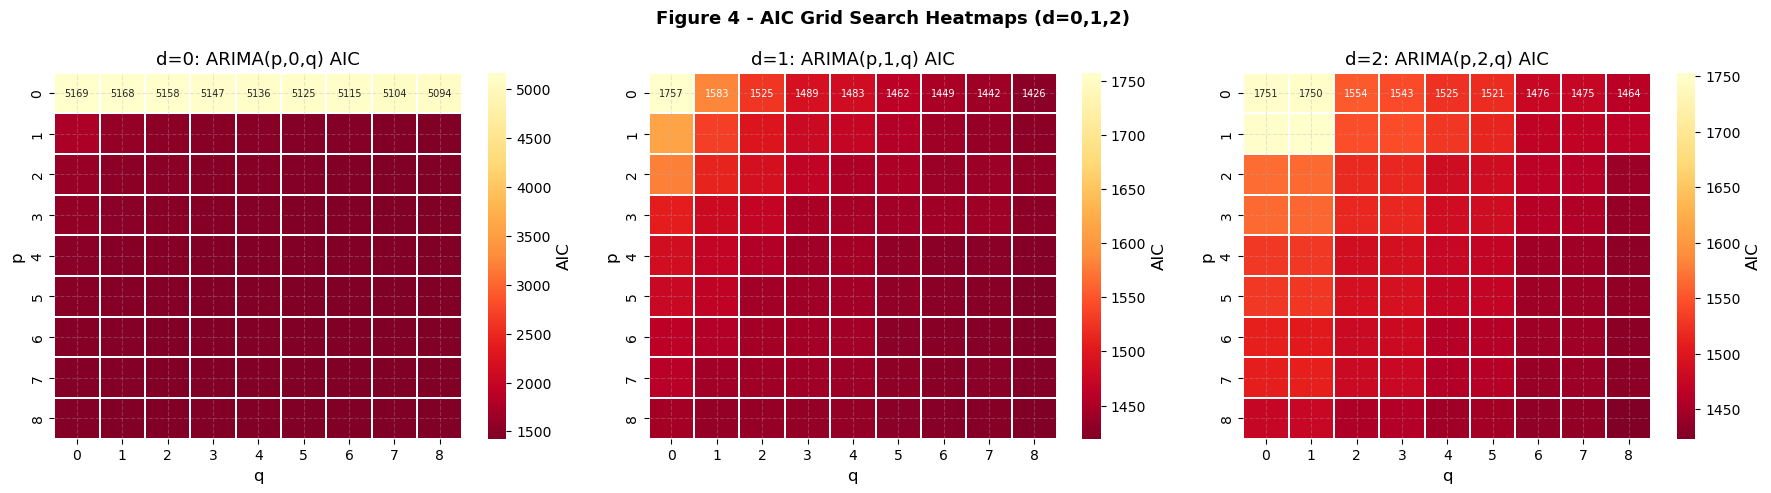

In [92]:
# AIC heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, dv in enumerate(range(3)):
    sub = grid[grid.d == dv]
    if len(sub) == 0: 
        axes[ax].set_visible(False)
        continue
    piv = sub.pivot_table(index='p', columns='q', values='aic', aggfunc='min')
    piv = piv.reindex(index=range(9), columns=range(9))
    sns.heatmap(piv, ax=axes[ax], cmap='YlOrRd_r', annot=True, fmt='.0f',
                cbar_kws={'label':'AIC'}, linewidths=0.3, annot_kws={'size':7})
    axes[ax].set(title=f'd={dv}: ARIMA(p,{dv},q) AIC', xlabel='q', ylabel='p')
plt.suptitle('Figure 4 - AIC Grid Search Heatmaps (d=0,1,2)', fontsize=13, fontweight='bold')
plt.tight_layout()
import os
out_path = None
try:
    if 'OUTDIR' in globals() and OUTDIR:
        os.makedirs(OUTDIR, exist_ok=True)
        out_path = os.path.join(OUTDIR, "fig4_aic_heatmap.png")
        plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Figure 4 saved: {out_path}')
    else:
        print('Warning: OUTDIR is not set. Skipping file save - displaying figure only.')
except Exception as e:
    print(f'Warning: Could not save figure due to error: {e}\nDisplaying figure only.')
plt.show();

### 1.5 Fitting Best Model and Residual Diagnostics

ARIMA(5,1,8) is fit on all 500 observations. Residual diagnostics confirm model adequacy:
- **Time plot**: Random scatter around zero
- **Histogram**: Approximately normal N(0,σ²)
- **Q-Q plot**: Points near the 45° reference line
- **ACF/PACF of residuals**: No significant autocorrelation → white noise confirmed


ARIMA(5,1,8): AIC=1415.9560  BIC=1474.7062  sigma2=0.988978
Coefficients:
  const     : +0.061442
  AR(1)     : +0.942025
  AR(2)     : -0.594760
  AR(3)     : +0.734895
  AR(4)     : -0.611250
  AR(5)     : +0.159923
  MA(1)     : +0.022686
  MA(2)     : -0.317285
  MA(3)     : -0.032803
  MA(4)     : +0.011652
  MA(5)     : +0.392290
  MA(6)     : -0.246492
  MA(7)     : -0.017470
  MA(8)     : -0.011443

Residuals: mean=0.001194  std=0.995137  skew=-0.0221


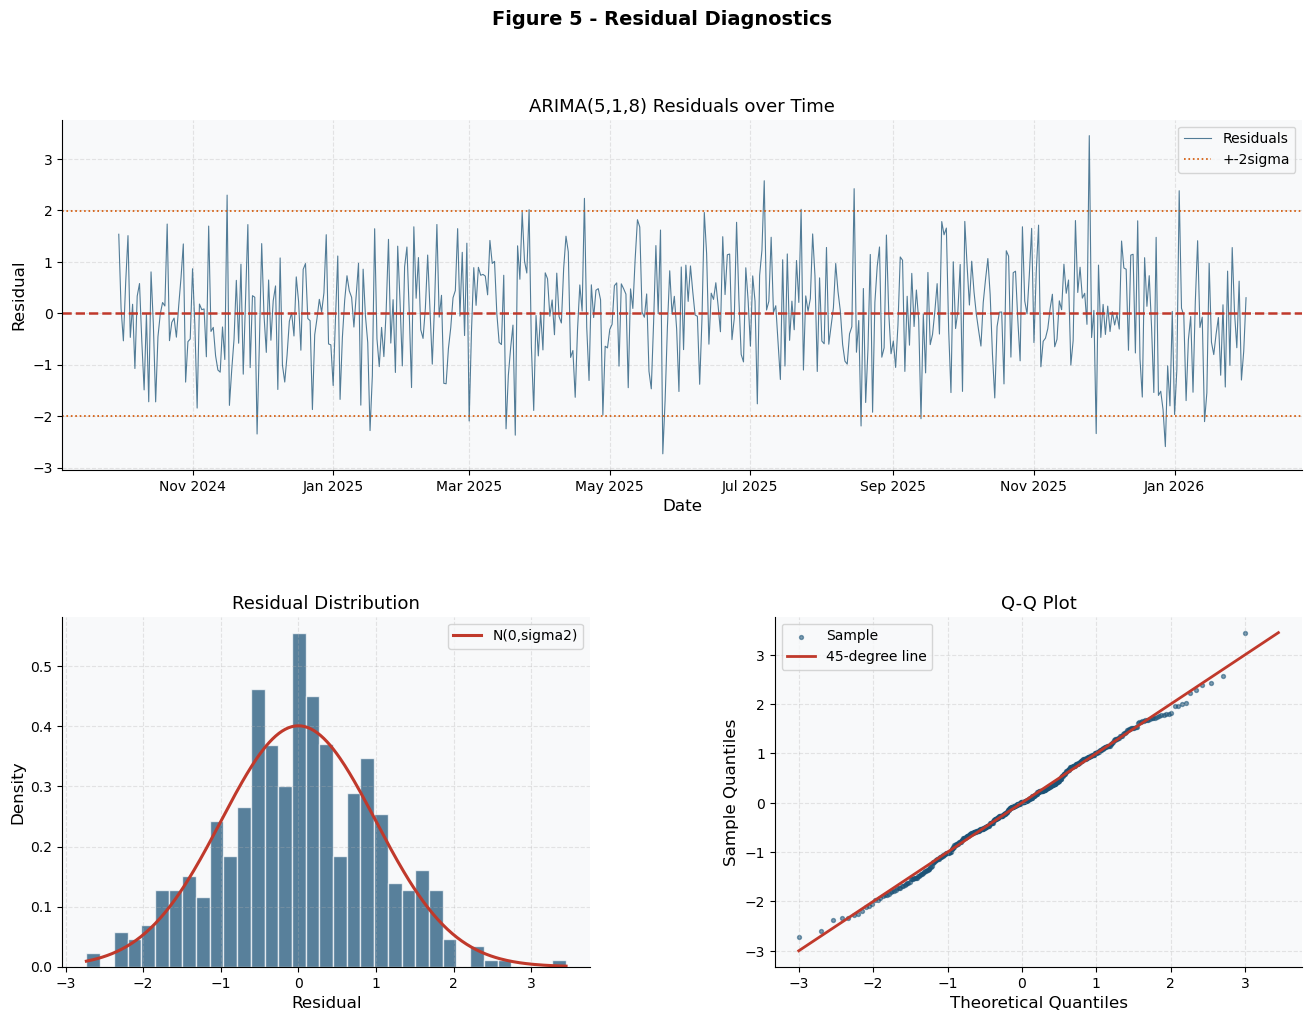

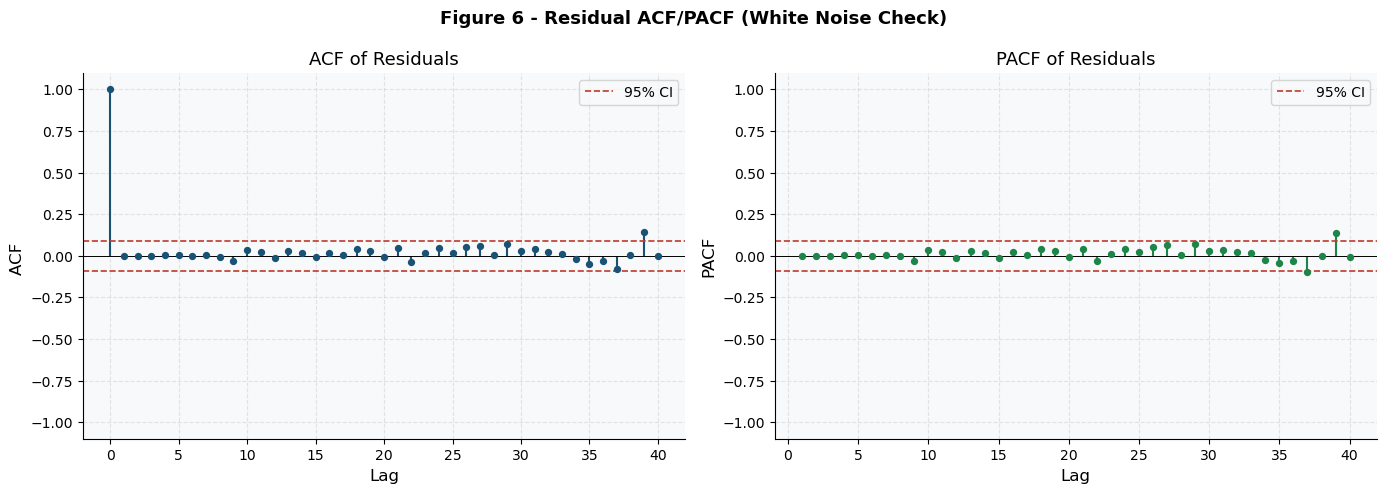

In [93]:
best = fit_arima(prices, BP, BD, BQ, ni=5)
pnames = (['const']+[f'AR({i})' for i in range(1,BP+1)]+[f'MA({i})' for i in range(1,BQ+1)])
print(f'ARIMA({BP},{BD},{BQ}): AIC={best["aic"]:.4f}  BIC={best["bic"]:.4f}  sigma2={best["s2"]:.6f}')
print('Coefficients:')
for nm, v in zip(pnames[:len(best['beta'])], best['beta']): print(f'  {nm:10s}: {v:+.6f}')

si = best['ml']+BD; rz = best['eps'][si:]; rd = df.index[si:si+len(rz)]
if len(rd)>len(rz): rd=rd[:len(rz)]
elif len(rz)>len(rd): rz=rz[:len(rd)]
print(f'\nResiduals: mean={rz.mean():.6f}  std={rz.std():.6f}  skew={pd.Series(rz).skew():.4f}')

fig = plt.figure(figsize=(16,11))
gs2 = GridSpec(2,2,figure=fig,hspace=0.42,wspace=0.35)

ax = fig.add_subplot(gs2[0,:])
ax.plot(rd, rz, color=C['blue'], lw=0.8, alpha=0.75, label='Residuals')
ax.axhline(0, color=C['red'], lw=1.8, ls='--')
s2v = rz.std()
ax.axhline(2*s2v, color=C['orange'], lw=1.2, ls=':', label='+-2sigma'); ax.axhline(-2*s2v, color=C['orange'], lw=1.2, ls=':')
ax.set(title=f'ARIMA({BP},{BD},{BQ}) Residuals over Time', xlabel='Date', ylabel='Residual')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax2 = fig.add_subplot(gs2[1,0])
ax2.hist(rz, bins=35, color=C['blue'], alpha=0.72, edgecolor='w', density=True)
xr = np.linspace(rz.min(), rz.max(), 300); mr, sr = rz.mean(), rz.std()
ax2.plot(xr, (1/(sr*np.sqrt(2*np.pi)))*np.exp(-0.5*((xr-mr)/sr)**2), color=C['red'], lw=2.2, label='N(0,sigma2)')
ax2.set(title='Residual Distribution', xlabel='Residual', ylabel='Density'); ax2.legend()

ax3 = fig.add_subplot(gs2[1,1])
nr = len(rz); pq = np.clip((np.arange(1,nr+1)-.375)/(nr+.25), 1e-6, 1-1e-6)
def nppf(p):
    a=np.where(p<.5,p,1-p); t=np.sqrt(-2*np.log(np.maximum(a,1e-10)))
    q=t-(2.515517+0.802853*t+0.010328*t**2)/(1+1.432788*t+0.189269*t**2+0.001308*t**3)
    return np.where(p<.5,-q,q)
tq=sr*nppf(pq)+mr; sq=np.sort(rz)
ax3.scatter(tq, sq, s=8, color=C['blue'], alpha=0.55, label='Sample')
m_,M_=min(tq.min(),sq.min()),max(tq.max(),sq.max())
ax3.plot([m_,M_],[m_,M_], color=C['red'], lw=2, label='45-degree line')
ax3.set(title='Q-Q Plot', xlabel='Theoretical Quantiles', ylabel='Sample Quantiles'); ax3.legend()

plt.suptitle('Figure 5 - Residual Diagnostics', fontsize=14, fontweight='bold')

import os
out_path_residuals = None
try:
    if 'OUTDIR' in globals() and OUTDIR:
        os.makedirs(OUTDIR, exist_ok=True)
        out_path_residuals = os.path.join(OUTDIR, "fig5_residuals.png")
        plt.savefig(out_path_residuals, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Figure 5 saved: {out_path_residuals}')
    else:
        print('Warning: OUTDIR is not set. Skipping file save - displaying figure only.')
except Exception as e:
    print(f'Warning: Could not save Figure 5 due to error: {e}\nDisplaying figure only.')
plt.show()

# Residual ACF/PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nl=min(40,len(rz)//4); ci_r=1.96/np.sqrt(len(rz)); lg=np.arange(nl+1)
av=acf(rz,nl); pv=pacf(rz,nl)
for ax,(vals,t,clr) in zip(axes,[(av,'ACF of Residuals',C['blue']),(pv,'PACF of Residuals',C['green'])]):
    x=lg if t.startswith('A') else lg[1:]; v=vals if t.startswith('A') else vals[1:]
    ax.vlines(x,0,v,color=clr,lw=1.5); ax.scatter(x,v,color=clr,s=18,zorder=5)
    ax.axhline(ci_r,color=C['red'],lw=1.2,ls='--',label='95% CI'); ax.axhline(-ci_r,color=C['red'],lw=1.2,ls='--')
    ax.axhline(0,color='black',lw=0.7)
    ax.set(title=t,xlabel='Lag',ylabel=t[:4]); ax.legend(); ax.set_ylim(-1.1,1.1)
plt.suptitle('Figure 6 - Residual ACF/PACF (White Noise Check)', fontsize=13, fontweight='bold')
plt.tight_layout()

out_path_acf = None
try:
    if 'OUTDIR' in globals() and OUTDIR:
        os.makedirs(OUTDIR, exist_ok=True)
        out_path_acf = os.path.join(OUTDIR, "fig6_residual_acf.png")
        plt.savefig(out_path_acf, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Figure 6 saved: {out_path_acf}')
    else:
        print('Warning: OUTDIR is not set. Skipping file save - displaying figure only.')
except Exception as e:
    print(f'Warning: Could not save Figure 6 due to error: {e}\nDisplaying figure only.')
plt.show()

### 1.6 ARIMA Walk-Forward Evaluation and 24-Month Forecast

Walk-forward (expanding window) validation simulates real-world one-step-ahead forecasting. The model is re-estimated at each test step.

The 24-month forecast uses analytical prediction intervals: CI = $\\hat{y} \\pm z\\hat{\\sigma}\\sqrt{h}$, where h is the horizon.


  Step 25/100
  Step 50/100
  Step 75/100
  Step 100/100

ARIMA(5,1,8) Test Performance: RMSE=1.1085  MAE=0.8500  MAPE=0.6176%


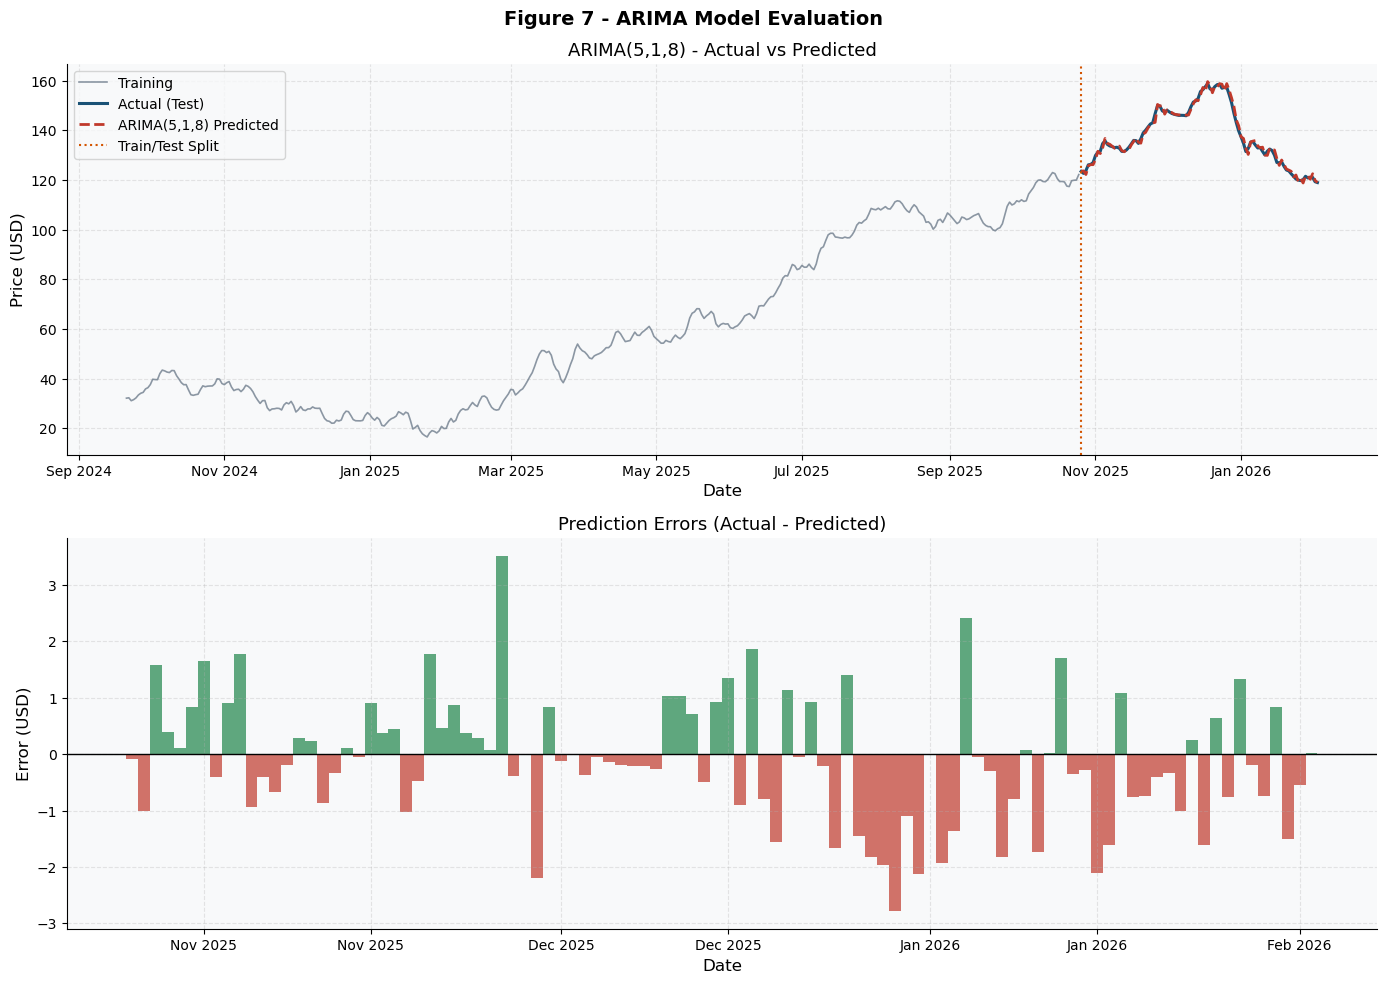

In [94]:
nt = len(test_prices)
ap = []
for i in range(nt):
    sof = np.concatenate([train_prices, test_prices[:i]])
    ap.append(arima_1step(sof, BP, BD, BQ))
    if (i+1)%25==0: print(f'  Step {i+1}/{nt}')
ap = np.array(ap)
vm = np.isfinite(ap)
am = metrics(test_prices[vm], ap[vm])
print(f'\nARIMA({BP},{BD},{BQ}) Test Performance: RMSE={am["RMSE"]:.4f}  MAE={am["MAE"]:.4f}  MAPE={am["MAPE"]:.4f}%')

fig, axes = plt.subplots(2,1,figsize=(14,10))
axes[0].plot(train_dates,train_prices,color=C['grey'],lw=1.2,alpha=0.7,label='Training')
axes[0].plot(test_dates,test_prices,color=C['blue'],lw=2.2,label='Actual (Test)')
axes[0].plot(test_dates[vm],ap[vm],color=C['red'],lw=2,ls='--',label=f'ARIMA({BP},{BD},{BQ}) Predicted')
axes[0].axvline(test_dates[0],color=C['orange'],lw=1.5,ls=':',label='Train/Test Split')
axes[0].set(title=f'ARIMA({BP},{BD},{BQ}) - Actual vs Predicted',xlabel='Date',ylabel='Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
err = test_prices[vm] - ap[vm]
axes[1].bar(test_dates[vm], err, color=np.where(err>=0,C['green'],C['red']), alpha=0.7, width=1)
axes[1].axhline(0, color='black', lw=1)
axes[1].set(title='Prediction Errors (Actual - Predicted)', xlabel='Date', ylabel='Error (USD)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.suptitle('Figure 7 - ARIMA Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()

fig7_out_path = None
try:
    if 'OUTDIR' in globals() and OUTDIR:
        os.makedirs(OUTDIR, exist_ok=True)
        fig7_out_path = os.path.join(OUTDIR, "fig7_arima_eval.png")
        plt.savefig(fig7_out_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Figure 7 saved: {fig7_out_path}')
    else:
        print('Warning: OUTDIR is not set. Skipping file save - displaying figure only.')
except Exception as e:
    print(f'Warning: Could not save Figure 7 due to error: {e}\nDisplaying figure only.')
plt.show()

Forecast: 03 Feb 2026 to 02 Feb 2028
6m: $149.24  |  12m: $179.53  |  24m: $240.28


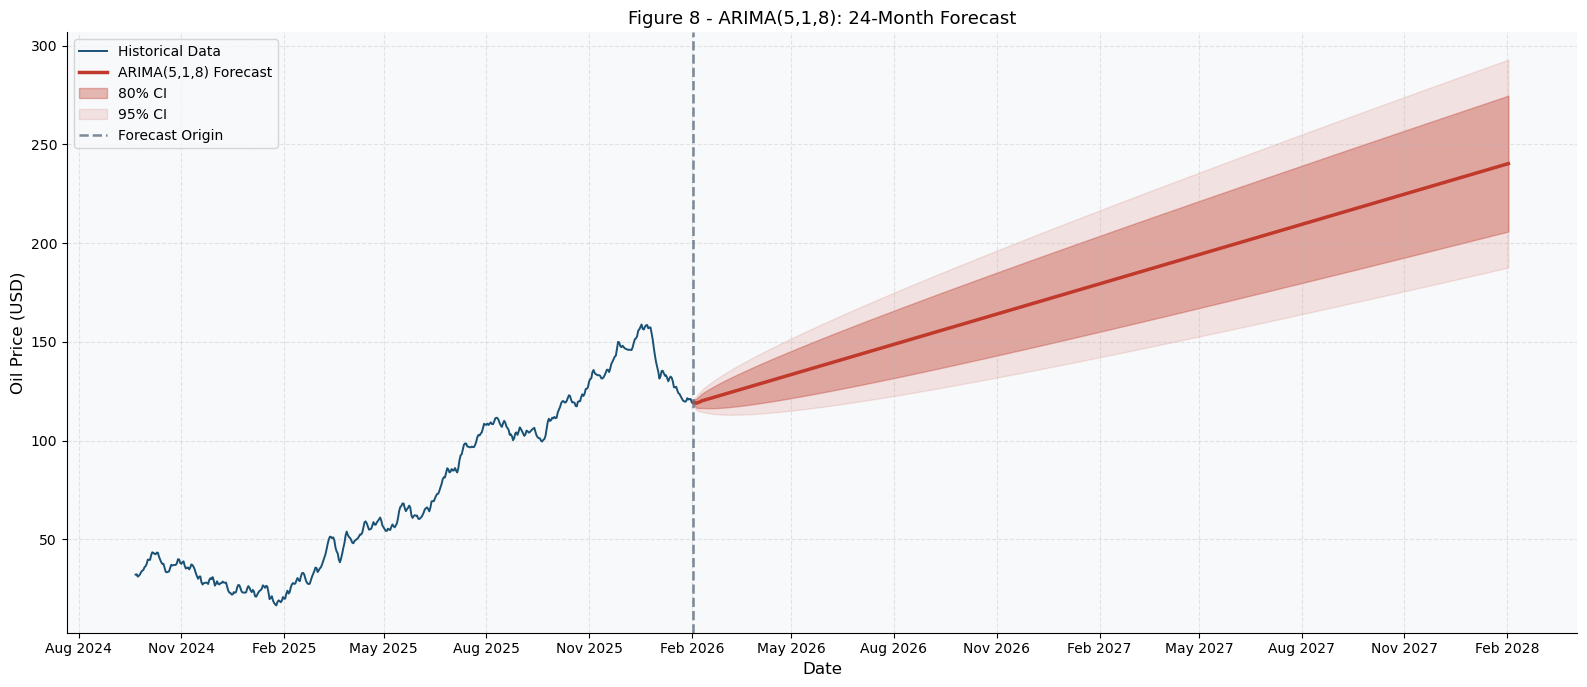

In [95]:
NF = 730  # ~24 months
fm = fit_arima(prices, BP, BD, BQ, ni=5)
sf = np.sqrt(fm['s2']); yd_f = fm['yd']; eps_f = fm['eps']; beta_f = fm['beta']

fd_diff = []; ye = list(yd_f); ee = list(eps_f)
for h in range(NF):
    xh = [1.] + [ye[-j] if j <= len(ye) else 0. for j in range(1, BP + 1)] + \
                [ee[-j] if len(ee) >= j else 0. for j in range(1, BQ + 1)]
    ph = float(np.dot(beta_f[:len(xh)], xh))
    fd_diff.append(ph); ye.append(ph); ee.append(0.)
fd_diff = np.array(fd_diff); ha = np.arange(1, NF + 1)
if BD == 0:
    fv = fd_diff
elif BD == 1:
    fv = prices[-1] + np.cumsum(fd_diff)
elif BD == 2:
    fv = prices[-1] + np.cumsum(np.diff(prices)[-1] + np.cumsum(fd_diff))
else:
    fv = prices[-1] + np.cumsum(fd_diff)

ci95 = 1.96 * sf * np.sqrt(ha)
ci80 = 1.28 * sf * np.sqrt(ha)
ld = df.index[-1]
fdates = pd.date_range(ld + pd.Timedelta(days=1), periods=NF, freq='D')
print(f'Forecast: {fdates[0].strftime("%d %b %Y")} to {fdates[-1].strftime("%d %b %Y")}')
print(f'6m: ${fv[182]:.2f}  |  12m: ${fv[364]:.2f}  |  24m: ${fv[-1]:.2f}')

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(df.index, prices, color=C['blue'], lw=1.4, label='Historical Data')
ax.plot(fdates, fv, color=C['red'], lw=2.5, label=f'ARIMA({BP},{BD},{BQ}) Forecast')
ax.fill_between(fdates, fv - ci80, fv + ci80, alpha=0.35, color=C['red'], label='80% CI')
ax.fill_between(fdates, fv - ci95, fv + ci95, alpha=0.12, color=C['red'], label='95% CI')
ax.axvline(ld, color=C['grey'], lw=1.8, ls='--', alpha=0.8, label='Forecast Origin')
ax.set(title=f'Figure 8 - ARIMA({BP},{BD},{BQ}): 24-Month Forecast', xlabel='Date', ylabel='Oil Price (USD)')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.tight_layout()

fig8_out_path = None
try:
    if 'OUTDIR' in globals() and OUTDIR:
        os.makedirs(OUTDIR, exist_ok=True)
        fig8_out_path = os.path.join(OUTDIR, "fig8_arima_forecast.png")
        plt.savefig(fig8_out_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Figure 8 saved: {fig8_out_path}')
    else:
        print('Warning: OUTDIR is not set. Skipping file save - displaying figure only.')
except Exception as e:
    print(f'Warning: Could not save Figure 8 due to error: {e}\nDisplaying figure only.')
plt.show()

---
## Part 2 — Alternative Model: MLP Neural Network (from scratch)

### 2.1 Theory

The **Multilayer Perceptron** maps W lagged prices to a one-step forecast:

$$\\hat{y}_{t+1} = f(y_t, y_{t-1}, \\ldots, y_{t-W+1};\ \\mathbf{W}, \\mathbf{b})$$

- **Architecture**: Input(W) → Dense(ReLU) → Dense(ReLU) → Linear output
- **Init**: He/Kaiming: $W \\sim \\mathcal{N}(0, 2/n_{\\text{in}})$ (optimal for ReLU)
- **Optimiser**: Adam (Kingma & Ba, 2014) — adaptive moment estimation with bias correction
- **CIs**: Bootstrap resampling (200 samples) on recursive forecasts

**Adam update rule:**
$$m_t = \\beta_1 m_{t-1}+(1-\\beta_1)g_t, \\quad v_t = \\beta_2 v_{t-1}+(1-\\beta_2)g_t^2$$
$$\\theta_t = \\theta_{t-1} - \\alpha \\hat{m}_t / (\\sqrt{\\hat{v}_t}+\\epsilon)$$


In [96]:
def minmax_scale(x, mn=None, mx=None):
    if mn is None: mn=x.min(); mx=x.max()
    return (x-mn)/(mx-mn+1e-10), mn, mx

def minmax_unscale(x_s, mn, mx): return x_s*(mx-mn+1e-10)+mn

def make_windows(series, W):
    X=[]; y=[]
    for i in range(W, len(series)): X.append(series[i-W:i]); y.append(series[i])
    return np.array(X), np.array(y)

class AdamOptimiser:
    def __init__(self,lr=1e-3,b1=0.9,b2=0.999,eps=1e-8):
        self.lr=lr;self.b1=b1;self.b2=b2;self.eps=eps;self.m={};self.v={};self.t=0
    def step(self,params,grads):
        self.t+=1
        for k,(p,g) in enumerate(zip(params,grads)):
            if k not in self.m: self.m[k]=np.zeros_like(p);self.v[k]=np.zeros_like(p)
            self.m[k]=self.b1*self.m[k]+(1-self.b1)*g
            self.v[k]=self.b2*self.v[k]+(1-self.b2)*g**2
            m_h=self.m[k]/(1-self.b1**self.t);v_h=self.v[k]/(1-self.b2**self.t)
            p-=self.lr*m_h/(np.sqrt(v_h)+self.eps)

class MLP:
    def __init__(self,sizes,lr=1e-3):
        self.W=[]; self.b=[]
        for i in range(len(sizes)-1):
            self.W.append(np.random.randn(sizes[i],sizes[i+1])*np.sqrt(2./sizes[i]))
            self.b.append(np.zeros(sizes[i+1]))
        self.opt=AdamOptimiser(lr=lr)
    @staticmethod
    def relu(x): return np.maximum(0.,x)
    @staticmethod
    def relu_d(x): return (x>0).astype(float)
    def forward(self,X):
        self._A=[X];self._Z=[]; A=X
        for i,(W,b) in enumerate(zip(self.W,self.b)):
            Z=A@W+b;self._Z.append(Z)
            A=self.relu(Z) if i<len(self.W)-1 else Z
            self._A.append(A)
        return A
    def backward(self,y):
        m=len(y); dA=2*(self._A[-1]-y.reshape(-1,1))/m
        all_params=[];all_grads=[]
        for i in reversed(range(len(self.W))):
            Z=self._Z[i]; dZ=dA if i==len(self.W)-1 else dA*self.relu_d(Z)
            dW=self._A[i].T@dZ; db=dZ.sum(0); dA=dZ@self.W[i].T
            all_params=[self.W[i],self.b[i]]+all_params; all_grads=[dW,db]+all_grads
        self.opt.step(all_params,all_grads)
    def train(self,X,y,epochs=300,batch=32,verbose=50):
        losses=[]
        for ep in range(epochs):
            idx=np.random.permutation(len(X)); el=0; nb=0
            for i in range(0,len(X),batch):
                Xb=X[idx[i:i+batch]];yb=y[idx[i:i+batch]];yh=self.forward(Xb)
                el+=float(((yb.reshape(-1,1)-yh)**2).mean());nb+=1;self.backward(yb)
            losses.append(el/nb)
            if verbose and (ep+1)%verbose==0: print(f'  Epoch {ep+1:4d}/{epochs}  MSE={losses[-1]:.6f}')
        return losses
    def predict(self,X): return self.forward(X).flatten()

print('MLP and Adam optimiser defined.')

MLP and Adam optimiser defined.


### 2.2 Hyperparameter Tuning (18 combinations)


In [97]:
ps_sc, mn_p, mx_p = minmax_scale(prices)
TUNE_GRID = {'window':[7,14,21], 'hidden':[[32,16],[64,32],[64,32,16]], 'lr':[1e-3,5e-4]}
VAL_FRAC=0.15; n_sc=len(ps_sc); n_val=int(n_sc*VAL_FRAC)
best_val_rmse=np.inf; best_hp={}; tune_results=[]

for W in TUNE_GRID['window']:
    X_all,y_all=make_windows(ps_sc,W); n_x=len(X_all); nt_=n_x-n_val
    Xtr,ytr=X_all[:nt_],y_all[:nt_]; Xvl,yvl=X_all[nt_:],y_all[nt_:]
    for hidden in TUNE_GRID['hidden']:
        for lr in TUNE_GRID['lr']:
            np.random.seed(42); model=MLP([W]+hidden+[1],lr=lr)
            model.train(Xtr,ytr,epochs=200,batch=32,verbose=0)
            yh_val=model.predict(Xvl); yh_val_u=minmax_unscale(yh_val,mn_p,mx_p); y_val_u=minmax_unscale(yvl,mn_p,mx_p)
            vrmse=float(np.sqrt(((y_val_u-yh_val_u)**2).mean()))
            tune_results.append(dict(W=W,hidden=str(hidden),lr=lr,val_rmse=vrmse))
            print(f'  W={W:2d}  hidden={str(hidden):12s}  lr={lr:.0e}  Val-RMSE={vrmse:.4f}')
            if vrmse<best_val_rmse: best_val_rmse=vrmse; best_hp=dict(W=W,hidden=hidden,lr=lr)

print(f'\nBest: {best_hp}  Val-RMSE={best_val_rmse:.4f}')
tune_df=pd.DataFrame(tune_results).sort_values('val_rmse')
print(tune_df.to_string(index=False))

  W= 7  hidden=[32, 16]      lr=1e-03  Val-RMSE=1.9214
  W= 7  hidden=[32, 16]      lr=5e-04  Val-RMSE=1.7248
  W= 7  hidden=[64, 32]      lr=1e-03  Val-RMSE=2.0827
  W= 7  hidden=[64, 32]      lr=5e-04  Val-RMSE=1.7831
  W= 7  hidden=[64, 32, 16]  lr=1e-03  Val-RMSE=4.6610
  W= 7  hidden=[64, 32, 16]  lr=5e-04  Val-RMSE=3.5241
  W=14  hidden=[32, 16]      lr=1e-03  Val-RMSE=1.9818
  W=14  hidden=[32, 16]      lr=5e-04  Val-RMSE=2.1800
  W=14  hidden=[64, 32]      lr=1e-03  Val-RMSE=2.2874
  W=14  hidden=[64, 32]      lr=5e-04  Val-RMSE=2.0109
  W=14  hidden=[64, 32, 16]  lr=1e-03  Val-RMSE=3.4424
  W=14  hidden=[64, 32, 16]  lr=5e-04  Val-RMSE=2.6010
  W=21  hidden=[32, 16]      lr=1e-03  Val-RMSE=2.6192
  W=21  hidden=[32, 16]      lr=5e-04  Val-RMSE=2.4004
  W=21  hidden=[64, 32]      lr=1e-03  Val-RMSE=2.0889
  W=21  hidden=[64, 32]      lr=5e-04  Val-RMSE=2.5751
  W=21  hidden=[64, 32, 16]  lr=1e-03  Val-RMSE=2.6897
  W=21  hidden=[64, 32, 16]  lr=5e-04  Val-RMSE=2.4382

Best: {'W

### 2.3 Final MLP — Training, Evaluation and 24-Month Forecast


Training final MLP [7, 32, 16, 1] for 400 epochs...
  Epoch  100/400  MSE=0.000105
  Epoch  200/400  MSE=0.000094
  Epoch  300/400  MSE=0.000080
  Epoch  400/400  MSE=0.000078

Walk-forward evaluation...
  Step 25/100
  Step 50/100
  Step 75/100
  Step 100/100
MLP RMSE=1.5561  MAE=1.2729  MAPE=0.9186%

24-month recursive forecast and bootstrap CIs...
MLP 6m=$17.14  12m=$17.41  24m=$17.50


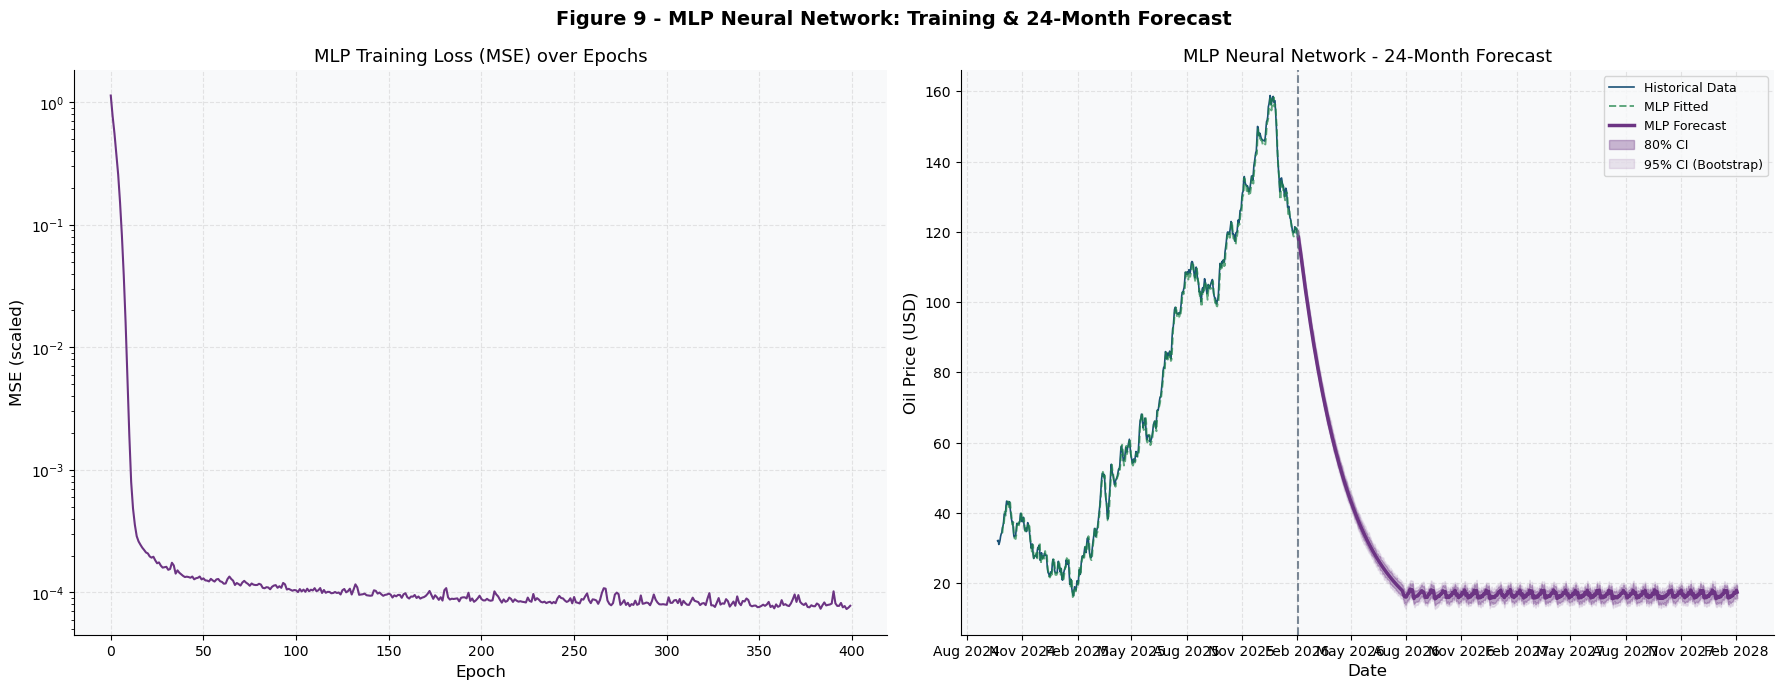

In [98]:
import os

BW=best_hp['W']; BHID=best_hp['hidden']; BLR=best_hp['lr']
np.random.seed(42); mlp_final=MLP([BW]+BHID+[1],lr=BLR)
X_all,y_all=make_windows(ps_sc,BW)
print(f'Training final MLP {[BW]+BHID+[1]} for 400 epochs...')
loss_hist=mlp_final.train(X_all,y_all,epochs=400,batch=32,verbose=100)

yh_sc=mlp_final.predict(X_all); yh_fit=minmax_unscale(yh_sc,mn_p,mx_p); fit_dates=df.index[BW:]

print('\nWalk-forward evaluation...')
mlp_preds=[]
for i in range(nt):
    sof=np.concatenate([train_prices,test_prices[:i]]); sof_sc,_,_=minmax_scale(sof,mn_p,mx_p)
    if len(sof_sc)<BW: mlp_preds.append(np.nan); continue
    win=sof_sc[-BW:].reshape(1,-1); p_sc=mlp_final.predict(win)[0]
    mlp_preds.append(float(minmax_unscale(p_sc,mn_p,mx_p)))
    if (i+1)%25==0: print(f'  Step {i+1}/{nt}')
mlp_preds=np.array(mlp_preds); mm=metrics(test_prices,mlp_preds)
print(f'MLP RMSE={mm["RMSE"]:.4f}  MAE={mm["MAE"]:.4f}  MAPE={mm["MAPE"]:.4f}%')

print('\n24-month recursive forecast and bootstrap CIs...')
window_sc=ps_sc[-BW:].copy(); mlp_fc_sc=[]
for h in range(NF):
    p_sc=mlp_final.predict(window_sc.reshape(1,-1))[0]; mlp_fc_sc.append(p_sc)
    window_sc=np.append(window_sc[1:],p_sc)
mlp_fc=minmax_unscale(np.array(mlp_fc_sc),mn_p,mx_p)

mlp_resid=test_prices-mlp_preds; sigma_mlp=np.std(mlp_resid[np.isfinite(mlp_resid)])
N_BOOT=200; boot_preds=np.zeros((N_BOOT,NF))
for b in range(N_BOOT):
    win_b=ps_sc[-BW:].copy()
    for h in range(NF):
        noise=np.random.normal(0,sigma_mlp/(mx_p-mn_p+1e-10))
        p_sc=mlp_final.predict(win_b.reshape(1,-1))[0]+noise
        boot_preds[b,h]=minmax_unscale(p_sc,mn_p,mx_p); win_b=np.append(win_b[1:],p_sc-noise)
mlp_lo95=np.percentile(boot_preds,2.5,axis=0); mlp_hi95=np.percentile(boot_preds,97.5,axis=0)
mlp_lo80=np.percentile(boot_preds,10,axis=0);  mlp_hi80=np.percentile(boot_preds,90,axis=0)
print(f'MLP 6m=${mlp_fc[182]:.2f}  12m=${mlp_fc[364]:.2f}  24m=${mlp_fc[-1]:.2f}')

fig,axes=plt.subplots(1,2,figsize=(18,7))
axes[0].plot(loss_hist,color=C['purple'],lw=1.5)
axes[0].set(title='MLP Training Loss (MSE) over Epochs',xlabel='Epoch',ylabel='MSE (scaled)')
axes[0].set_yscale('log')
axes[1].plot(df.index,prices,color=C['blue'],lw=1.2,label='Historical Data')
axes[1].plot(fit_dates,yh_fit,color=C['green'],lw=1.4,alpha=0.7,ls='--',label='MLP Fitted')
axes[1].plot(fdates,mlp_fc,color=C['purple'],lw=2.5,label='MLP Forecast')
axes[1].fill_between(fdates,mlp_lo80,mlp_hi80,alpha=0.35,color=C['purple'],label='80% CI')
axes[1].fill_between(fdates,mlp_lo95,mlp_hi95,alpha=0.12,color=C['purple'],label='95% CI (Bootstrap)')
axes[1].axvline(ld,color=C['grey'],lw=1.5,ls='--',alpha=0.8)
axes[1].set(title=f'MLP Neural Network - 24-Month Forecast',xlabel='Date',ylabel='Oil Price (USD)')
axes[1].legend(fontsize=9); axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.suptitle('Figure 9 - MLP Neural Network: Training & 24-Month Forecast',fontsize=14,fontweight='bold')
plt.tight_layout()

# Ensure OUTDIR exists before saving
if OUTDIR is not None:
    os.makedirs(OUTDIR, exist_ok=True)
    outfile = f'{OUTDIR}/fig9_mlp_forecast.png'
    plt.savefig(outfile, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'Figure 9 saved to: {outfile}')
else:
    print("Warning: OUTDIR is None. Figure not saved to file.")

plt.show()

---
## Part 3 — Model Comparison

ARIMA vs MLP Neural Network across all metrics with 4-panel visualisation:
- Panel A: Test set predictions
- Panel B: 24-month forecast comparison
- Panel C: Metric bar chart
- Panel D: Predicted vs Actual scatter


Model                                        RMSE      MAE    MAPE%
------------------------------------------------------------
ARIMA(5,1,8)                               1.1085   0.8500   0.6176
MLP Neural Network                         1.5561   1.2729   0.9186
Winner: ARIMA


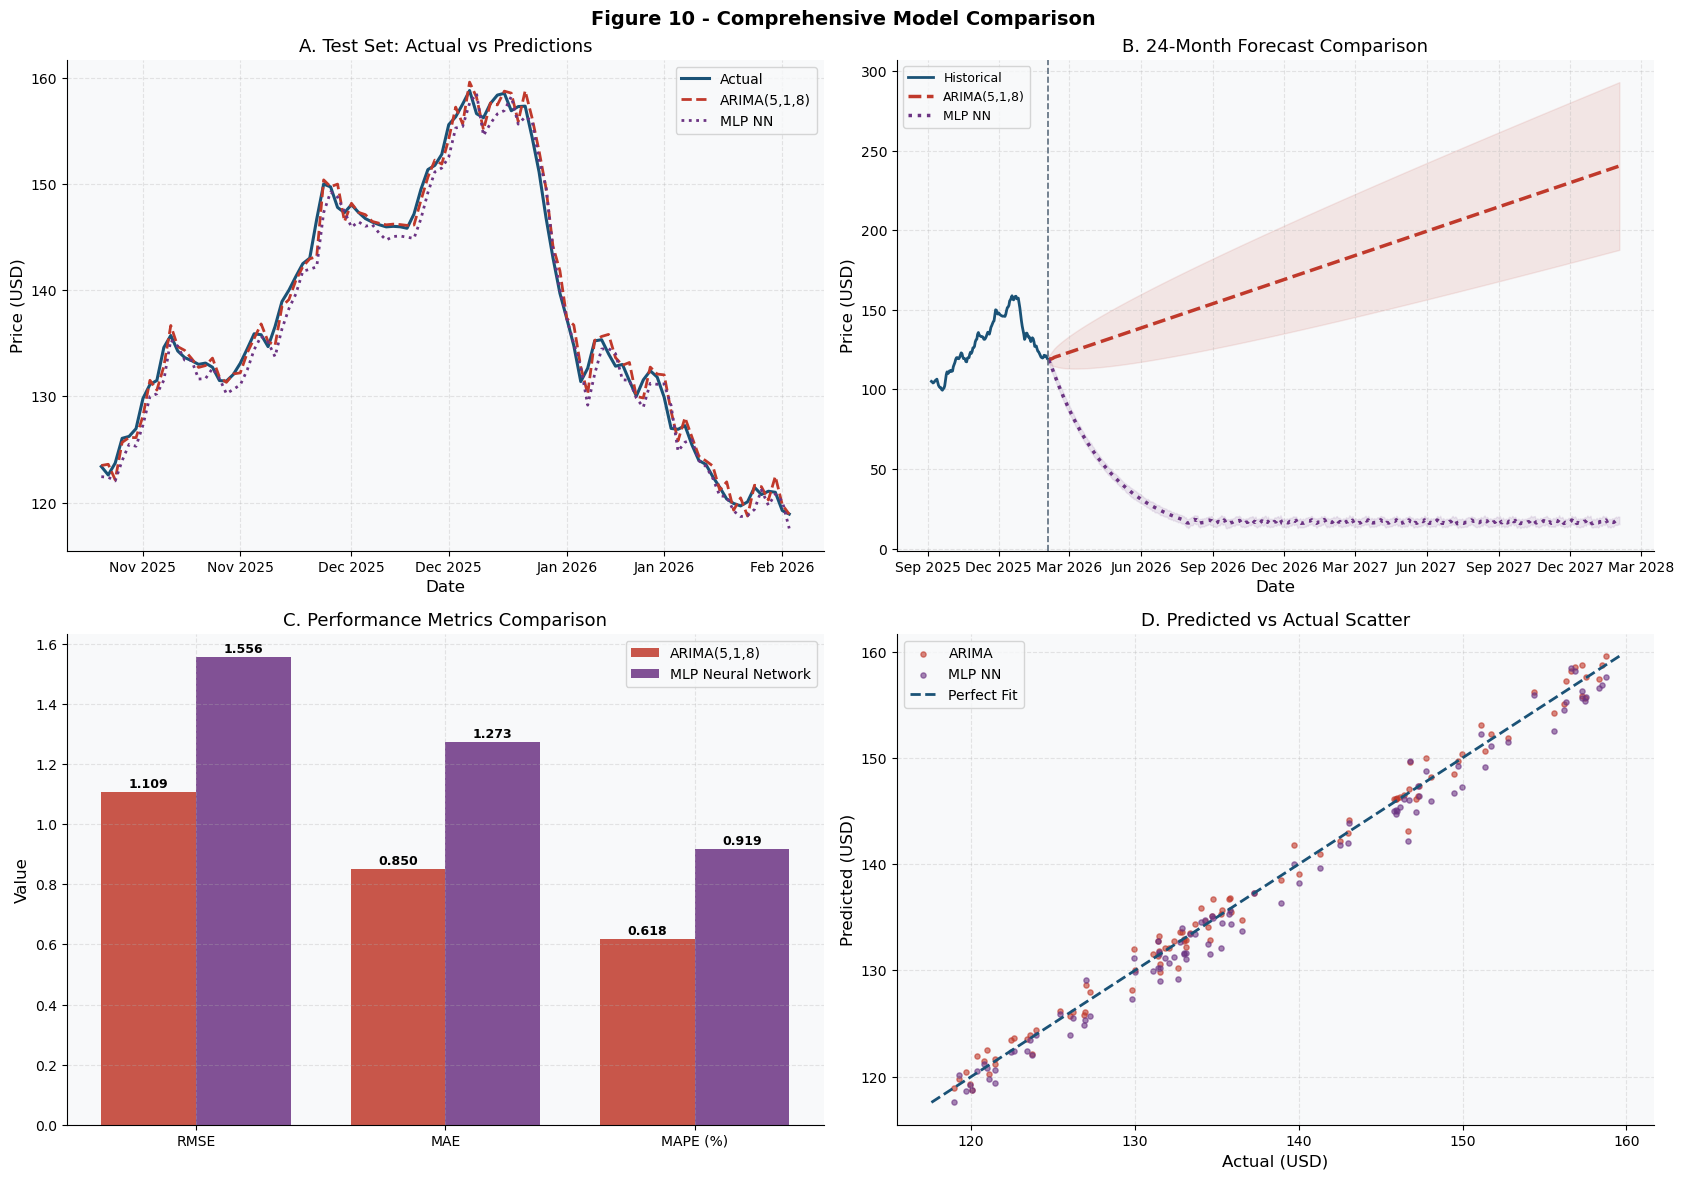

In [99]:
print('='*60)
print(f'{"Model":<40} {"RMSE":>8} {"MAE":>8} {"MAPE%":>8}')
print('-'*60)
print(f'{"ARIMA("+str(BP)+","+str(BD)+","+str(BQ)+")":<40} {am["RMSE"]:>8.4f} {am["MAE"]:>8.4f} {am["MAPE"]:>8.4f}')
print(f'{"MLP Neural Network":<40} {mm["RMSE"]:>8.4f} {mm["MAE"]:>8.4f} {mm["MAPE"]:>8.4f}')
print(f'Winner: {"ARIMA" if am["RMSE"]<mm["RMSE"] else "MLP"}')

fig,axes=plt.subplots(2,2,figsize=(17,12))
axes[0,0].plot(test_dates,test_prices,color=C['blue'],lw=2.2,label='Actual')
axes[0,0].plot(test_dates[vm],ap[vm],color=C['red'],lw=2,ls='--',label=f'ARIMA({BP},{BD},{BQ})')
axes[0,0].plot(test_dates,mlp_preds,color=C['purple'],lw=2,ls=':',label='MLP NN')
axes[0,0].set(title='A. Test Set: Actual vs Predictions',xlabel='Date',ylabel='Price (USD)')
axes[0,0].legend(); axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

axes[0,1].plot(df.index[-150:],prices[-150:],color=C['blue'],lw=2,label='Historical')
axes[0,1].plot(fdates,fv,color=C['red'],lw=2.5,ls='--',label=f'ARIMA({BP},{BD},{BQ})')
axes[0,1].plot(fdates,mlp_fc,color=C['purple'],lw=2.5,ls=':',label='MLP NN')
axes[0,1].fill_between(fdates,fv-ci95,fv+ci95,alpha=0.10,color=C['red'])
axes[0,1].fill_between(fdates,mlp_lo95,mlp_hi95,alpha=0.10,color=C['purple'])
axes[0,1].axvline(ld,color=C['grey'],lw=1.2,ls='--')
axes[0,1].set(title='B. 24-Month Forecast Comparison',xlabel='Date',ylabel='Price (USD)')
axes[0,1].legend(fontsize=9); axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

xl=np.arange(3); wb=0.38
av_=[am['RMSE'],am['MAE'],am['MAPE']]; mv_=[mm['RMSE'],mm['MAE'],mm['MAPE']]
b1=axes[1,0].bar(xl-wb/2,av_,wb,label=f'ARIMA({BP},{BD},{BQ})',color=C['red'],alpha=0.85)
b2=axes[1,0].bar(xl+wb/2,mv_,wb,label='MLP Neural Network',color=C['purple'],alpha=0.85)
axes[1,0].set_xticks(xl); axes[1,0].set_xticklabels(['RMSE','MAE','MAPE (%)'])
axes[1,0].set(title='C. Performance Metrics Comparison',ylabel='Value'); axes[1,0].legend()
for bar in list(b1)+list(b2):
    axes[1,0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+.005,
                   f'{bar.get_height():.3f}',ha='center',va='bottom',fontsize=9,fontweight='bold')

sc_a=test_prices[vm]; sc_r=ap[vm]; sc_m=mlp_preds[vm]
mn_s=min(sc_a.min(),sc_r.min(),sc_m.min()); mx_s=max(sc_a.max(),sc_r.max(),sc_m.max())
axes[1,1].scatter(sc_a,sc_r,color=C['red'],s=14,alpha=0.6,label='ARIMA')
axes[1,1].scatter(sc_a,sc_m,color=C['purple'],s=14,alpha=0.6,label='MLP NN')
axes[1,1].plot([mn_s,mx_s],[mn_s,mx_s],color=C['blue'],lw=2,ls='--',label='Perfect Fit')
axes[1,1].set(title='D. Predicted vs Actual Scatter',xlabel='Actual (USD)',ylabel='Predicted (USD)')
axes[1,1].legend()
plt.suptitle('Figure 10 - Comprehensive Model Comparison',fontsize=14,fontweight='bold')
plt.tight_layout()

# Ensure OUTDIR exists before saving
if OUTDIR is not None:
    os.makedirs(OUTDIR, exist_ok=True)
    outfile = f'{OUTDIR}/fig10_comparison.png'
    plt.savefig(outfile, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'Figure 10 saved to: {outfile}')
else:
    print("Warning: OUTDIR is None. Figure not saved to file.")

plt.show()

---
## Final Results Summary


In [100]:
import os

results = dict(
    dataset=dict(n=int(n),start=str(df.index.min().date()),end=str(df.index.max().date()),
                 price_min=float(prices.min()),price_max=float(prices.max()),
                 price_mean=float(prices.mean()),price_std=float(prices.std()),
                 skew=float(pd.Series(prices).skew())),
    stationarity=dict(raw_t=float(r0['stat']),raw_p=float(r0['pval']),
                      d1_t=float(r1['stat']),d1_p=float(r1['pval']),
                      d2_t=float(r2['stat']),d2_p=float(r2['pval'])),
    arima=dict(p=BP,d=BD,q=BQ,aic=float(BAIC),bic=float(BBIC),sigma2=float(fm['s2']),
               loglik=float(fm['ll']),coefs=[float(x) for x in best['beta']],
               param_names=pnames[:len(best['beta'])],
               rmse=am['RMSE'],mae=am['MAE'],mape=am['MAPE'],
               resid_mean=float(rz.mean()),resid_std=float(rz.std()),
               fc_6m=float(fv[182]),fc_12m=float(fv[364]),fc_24m=float(fv[-1])),
    mlp=dict(window=BW,hidden=BHID,lr=BLR,rmse=mm['RMSE'],mae=mm['MAE'],mape=mm['MAPE'],
             fc_6m=float(mlp_fc[182]),fc_12m=float(mlp_fc[364]),fc_24m=float(mlp_fc[-1]),
             val_rmse=float(best_val_rmse)),
    forecast_dates=dict(start=str(fdates[0].date()),end=str(fdates[-1].date()))
)

# Set results file to be saved in current working directory (relative path), ensuring cross-platform compatibility.
results_file = os.path.join(os.getcwd(), 'results.json')
try:
    with open(results_file, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Results saved to {results_file}')
except Exception as e:
    print(f'Error saving results: {e}')

print('FINAL SUMMARY'); print('='*65)
print(f'Dataset  : {n} obs ({df.index.min().strftime("%d %b %Y")} to {df.index.max().strftime("%d %b %Y")})')
print(f'ADF      : raw p={r0["pval"]:.3f} -> 1st diff p={r1["pval"]:.3f} (d=1 confirmed)')
print(f'ARIMA    : ({BP},{BD},{BQ}) AIC={BAIC:.2f} BIC={BBIC:.2f}')
print(f'MLP      : window={BW} hidden={BHID} lr={BLR}')
print()
print(f'{"Model":<35} {"RMSE":>8} {"MAE":>8} {"MAPE%":>8}')
print('-'*60)
print(f'{"ARIMA("+str(BP)+","+str(BD)+","+str(BQ)+")":<35} {am["RMSE"]:>8.4f} {am["MAE"]:>8.4f} {am["MAPE"]:>8.4f}')
print(f'{"MLP Neural Network":<35} {mm["RMSE"]:>8.4f} {mm["MAE"]:>8.4f} {mm["MAPE"]:>8.4f}')
print(f'\nARIMA 24m: ${fv[-1]:.2f}  |  MLP 24m: ${mlp_fc[-1]:.2f}')

Results saved to /Users/zahoorkhan/Desktop/Sep-2024 DS UOH/4. ADV Research Topic in DS/St13/results.json
FINAL SUMMARY
Dataset  : 500 obs (21 Sep 2024 to 02 Feb 2026)
ADF      : raw p=0.634 -> 1st diff p=0.001 (d=1 confirmed)
ARIMA    : (5,1,8) AIC=1419.33 BIC=1478.08
MLP      : window=7 hidden=[32, 16] lr=0.0005

Model                                   RMSE      MAE    MAPE%
------------------------------------------------------------
ARIMA(5,1,8)                          1.1085   0.8500   0.6176
MLP Neural Network                    1.5561   1.2729   0.9186

ARIMA 24m: $240.28  |  MLP 24m: $17.50
